Checkpoint 1: Imports and installations

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
appliances_energy_prediction = fetch_ucirepo(id=374) 
  
# data (as pandas dataframes) 
X = appliances_energy_prediction.data.features 
y = appliances_energy_prediction.data.targets 
  
# metadata 
appliances_energy_prediction.metadata
  
# variable information 
appliances_energy_prediction.variables


,name,role,type,demographic,description,units,missing_values
0,date,Feature,Date,None,None,NaN,no
1,Appliances,Target,Integer,None,None,Wh,no
2,lights,Feature,Integer,None,None,Wh,no
3,T1,Feature,Continuous,None,None,C,no
4,RH_1,Feature,Continuous,None,None,%,no
5,T2,Feature,Continuous,None,None,C,no
6,RH_2,Feature,Continuous,None,None,%,no
7,T3,Feature,Continuous,None,None,C,no
8,RH_3,Feature,Continuous,None,None,%,no
9,T4,Feature,Continuous,None,None,C,no


EDA

In [10]:
import pandas as pd

df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.dtypes)
df.head()


(19735, 29)
date               str
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
Appliances       int64
dtype: object


,date,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
0,2016-01-1117:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,60
1,2016-01-1117:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,60
2,2016-01-1117:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,50
3,2016-01-1117:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,50
4,2016-01-1117:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,60


Chechkpoint 3: Tipos correctos y calidad de datos

In [13]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d%H:%M:%S")
df = df.sort_values("date").reset_index(drop=True)

print(df["date"].min(), "->", df["date"].max())
print("nulos:", df.isna().sum().sum())
print("duplicados:", df.duplicated().sum())
print(df["date"].diff().value_counts().head())

2016-01-11 17:00:00 -> 2016-05-27 18:00:00
nulos: 0
duplicados: 0
date
0 days 00:10:00    19734
Name: count, dtype: int64


Checkpoint 4: El Target

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64
skew: 3.3863672147430623


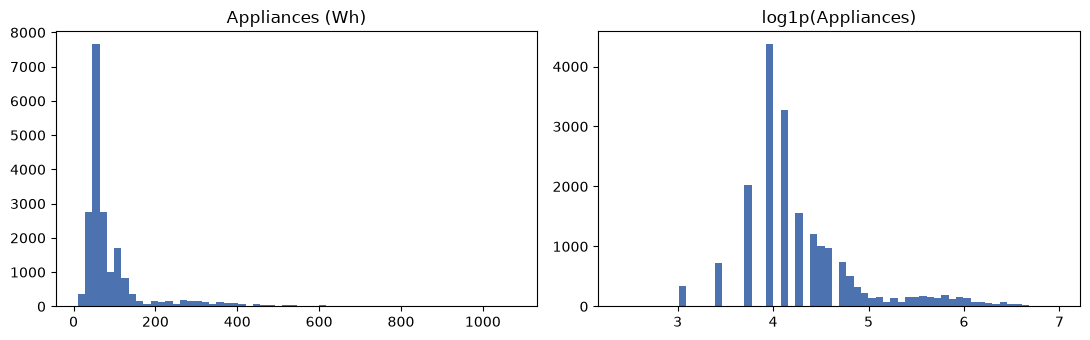

In [15]:
import numpy as np
import matplotlib.pyplot as plt

print(df["Appliances"].describe())
print("skew:", df["Appliances"].skew())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df["Appliances"], bins=60, color="#4C72B0")
axes[0].set_title("Appliances (Wh)")
axes[1].hist(np.log1p(df["Appliances"]), bins=60, color="#4C72B0")
axes[1].set_title("log1p(Appliances)")
plt.tight_layout()

Vamos a modelar log1p(Appliances)

Checkpoint 5: Los predictores: escala y variables sospechosas

In [16]:
features = df.drop(columns=["date", "Appliances"])

print(features.describe().T[["mean", "std", "min", "max"]])

print("\nrv1 == rv2:", (df["rv1"] == df["rv2"]).all())
print("\nlights:")
print(df["lights"].value_counts().sort_index())

                   mean        std         min         max
lights         3.801875   7.935988    0.000000   70.000000
T1            21.686571   1.606066   16.790000   26.260000
RH_1          40.259739   3.979299   27.023333   63.360000
T2            20.341219   2.192974   16.100000   29.856667
RH_2          40.420420   4.069813   20.463333   56.026667
T3            22.267611   2.006111   17.200000   29.236000
RH_3          39.242500   3.254576   28.766667   50.163333
T4            20.855335   2.042884   15.100000   26.200000
RH_4          39.026904   4.341321   27.660000   51.090000
T5            19.592106   1.844623   15.330000   25.795000
RH_5          50.949283   9.022034   29.815000   96.321667
T6             7.910939   6.090347   -6.065000   28.290000
RH_6          54.609083  31.149806    1.000000   99.900000
T7            20.267106   2.109993   15.390000   26.000000
RH_7          35.388200   5.114208   23.200000   51.400000
T8            22.029107   1.956162   16.306667   27.2300

1. Escalas totalmente distintas. Press_mm_hg con media 755 y lights con media 3.8. RH_6 con std 31 y T1 con std 1.6. Confirmado: hay que estandarizar antes de Ridge, Lasso y PCA. Sin eso, PCA te va a devolver una primera componente que es básicamente "presión atmosférica" solo porque tiene números grandes.

2. rv1 == rv2, idéntica. Columna duplicada, multicolinealidad perfecta. Decisión: eliminar rv2. Pero rv1 la DEJÁS, y te digo por qué: es ruido aleatorio puro, no tiene relación con el consumo. Si tu Lasso le pone coeficiente cero y tu Best Subset la deja afuera, tenés prueba de que la selección funciona. Es un canario en la mina.

3. lights es 77% ceros. No es una variable continua, es casi "¿hay luces prendidas o no?". Se queda, pero cuando veas su coeficiente interpretalo así.

Checkpoint 7: Correlaciones

lights         0.261143
T2             0.213784
T6             0.195821
T_out          0.175424
T3             0.166157
T1             0.159378
T8             0.152368
T4             0.131058
T7             0.109174
T5             0.108803
T9             0.091284
Windspeed      0.088046
RH_1           0.084757
Tdewpoint      0.055701
RH_5           0.024272
RH_3          -0.005733
RH_4          -0.006104
rv1           -0.010223
Visibility    -0.010854
Press_mm_hg   -0.072173
RH_2          -0.093405
RH_7          -0.095861
RH_9          -0.114999
RH_8          -0.164760
RH_6          -0.173072
RH_out        -0.225690
Name: log_appliances, dtype: float64


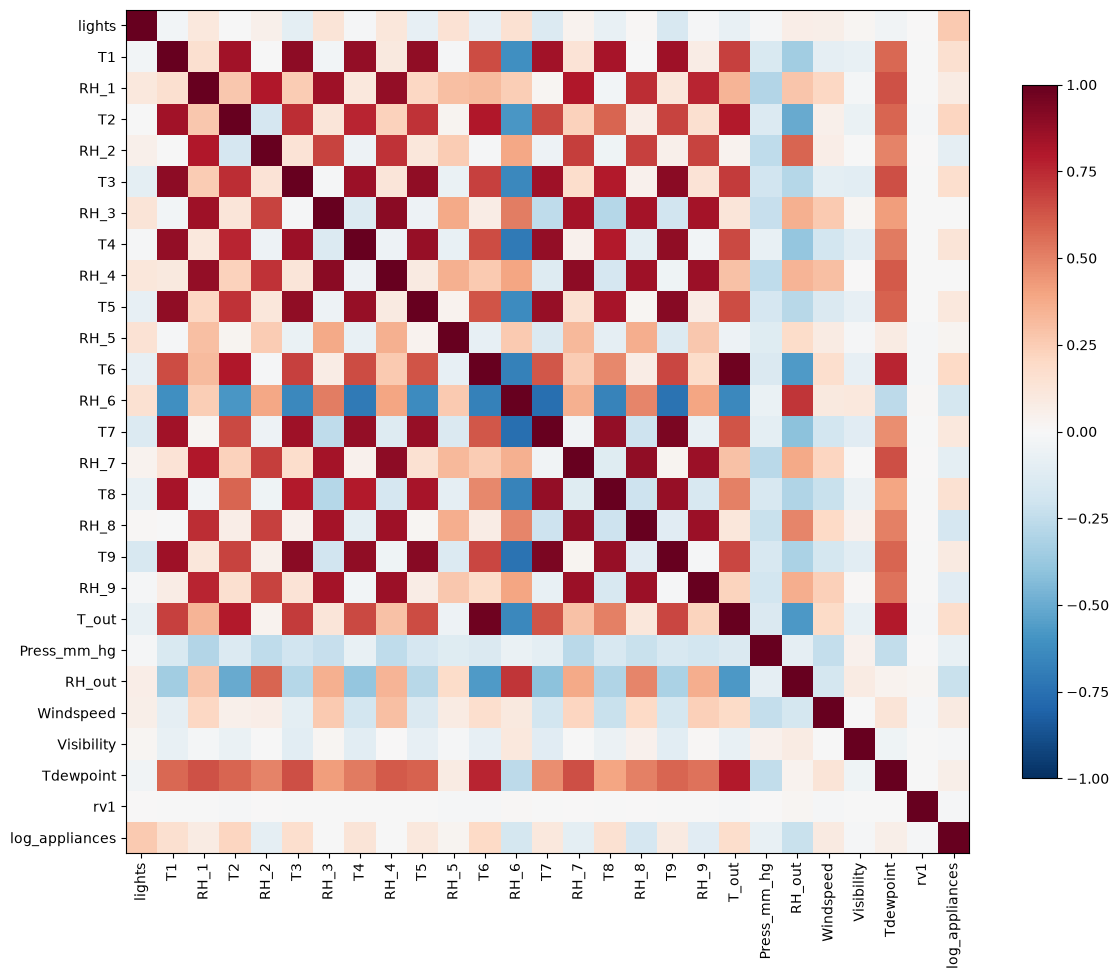

In [17]:
df = df.drop(columns=["rv2"])
df["log_appliances"] = np.log1p(df["Appliances"])

num = df.drop(columns=["date", "Appliances"])
corr = num.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

print(corr["log_appliances"].drop("log_appliances").sort_values(ascending=False))

Checkpoint 8: Cuantificar la multicolinealidad

In [18]:
pred_corr = num.drop(columns=["log_appliances"]).corr().abs()
upper = pred_corr.where(np.triu(np.ones(pred_corr.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
print(pairs[pairs > 0.9])

T6  T_out    0.974778
T7  T9       0.944776
T5  T9       0.911055
T3  T9       0.901324
dtype: float64


Cuatro pares por encima de 0.9, con T6/T_out casi idénticas.

Checkpoint 8:  El tiempo, que es donde vive la señal

hour              0.332743
hour_sin         -0.350402
hour_cos         -0.276257
is_weekend        0.042424
log_appliances    1.000000
Name: log_appliances, dtype: float64


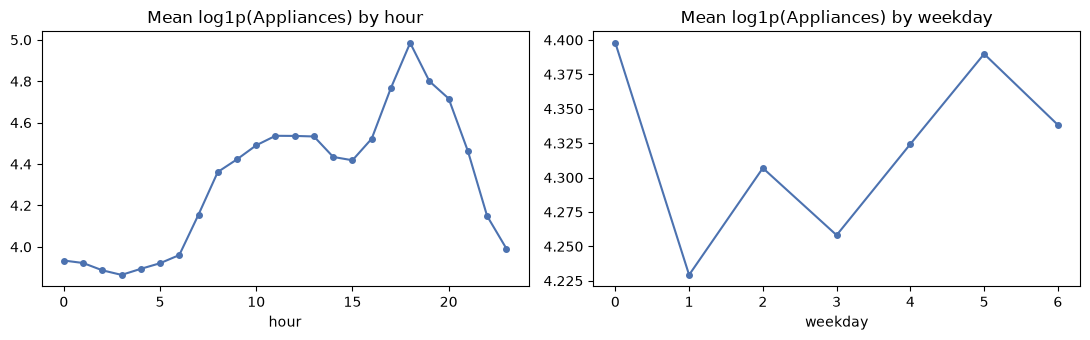

In [20]:
df["hour"] = df["date"].dt.hour
df["weekday"] = df["date"].dt.dayofweek  # 0 = Monday

# Cyclic encoding: hour 23 and hour 0 end up adjacent
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df.groupby("hour")["log_appliances"].mean().plot(ax=axes[0], color="#4C72B0", marker="o", ms=4)
axes[0].set_title("Mean log1p(Appliances) by hour")
df.groupby("weekday")["log_appliances"].mean().plot(ax=axes[1], color="#4C72B0", marker="o", ms=4)
axes[1].set_title("Mean log1p(Appliances) by weekday")
plt.tight_layout()

print(df[["hour", "hour_sin", "hour_cos", "is_weekend", "log_appliances"]].corr()["log_appliances"])


Checkpoint 9: Cierre del EDA: matriz de features y split temporal

In [26]:
from sklearn.preprocessing import StandardScaler

drop_cols = ["date", "Appliances", "log_appliances", "hour", "weekday"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_all = df[feature_cols]
y_all = df["log_appliances"]

# Temporal split: first 80% of the timeline trains, last 20% tests
split_idx = int(len(df) * 0.8)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

# Fit the scaler on train only, then apply to both
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("features:", len(feature_cols))
print("train:", X_train_s.shape, df["date"].iloc[0].date(), "->", df["date"].iloc[split_idx - 1].date())
print("test: ", X_test_s.shape, df["date"].iloc[split_idx].date(), "->", df["date"].iloc[-1].date())
print(X_train_s.describe().T[["mean", "std"]].round(2).head())

features: 29
train: (15788, 29) 2016-01-11 -> 2016-04-30
test:  (3947, 29) 2016-04-30 -> 2016-05-27
        mean  std
lights   0.0  1.0
T1      -0.0  1.0
RH_1     0.0  1.0
T2       0.0  1.0
RH_2    -0.0  1.0


Resumen EDA:

1. Dataset limpio: sin nulos, sin duplicados, serie continua de 10 minutos durante 4.5 meses. La fecha venía mal formateada y se parseó con formato explícito.
2. Target con skew 3.39 y cola larga a la derecha, discretizado en saltos de 10 Wh. Decisión: modelar log1p(Appliances).
3. rv2 idéntica a rv1: eliminada. rv1 se conserva como control de ruido para validar la selección de variables.
4. Escalas muy heterogéneas entre predictores. Decisión: estandarizar, ajustando el scaler solo con train.
5. Fuerte multicolinealidad: bloques de temperaturas y humedades correlacionados entre sí, cuatro pares por encima de 0.9. Se conservan todos a propósito para comparar cómo los trata cada método.
6. Correlación lineal débil con el target: ningún sensor supera 0.26. La hora del día, codificada cíclicamente, es el predictor más fuerte. Se agregan hour_sin, hour_cos e is_weekend.
7. Split temporal 80/20, sin shuffle, para evitar fuga de información entre filas vecinas.